<a href="https://colab.research.google.com/github/sh0g0-ikeda/nvidia-competition/blob/main/data_length.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

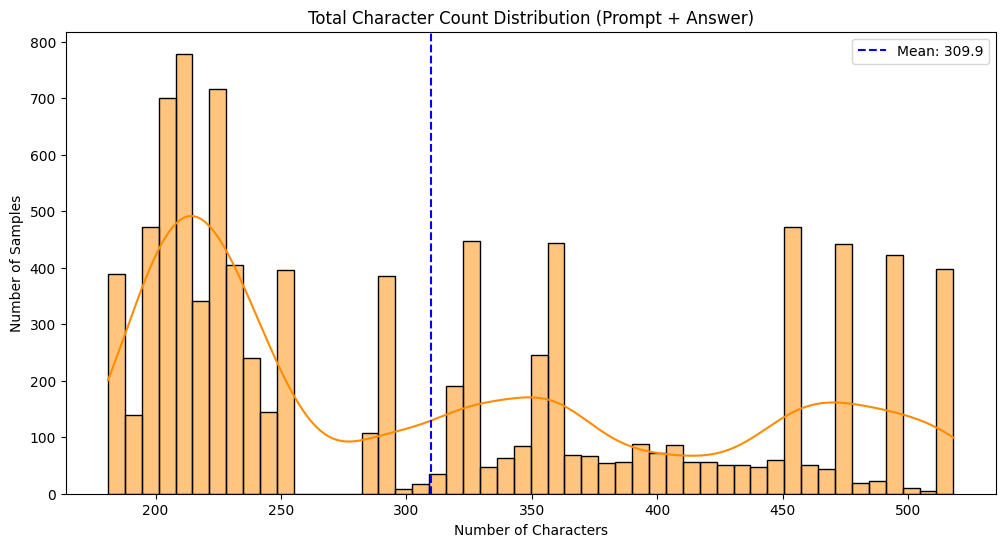

--- 文字数の統計データ ---
       len_prompt  len_answer  total_len
count      9500.0      9500.0     9500.0
mean        301.5         8.4      309.9
std         104.3         8.0      108.1
min         177.0         1.0      181.0
25%         209.0         4.0      213.0
50%         281.0         5.0      287.0
75%         371.0         8.0      396.0
max         510.0        39.0      518.0

10文字以下の極端に短いデータ: 0 件


In [2]:
#train dataの文字数計測
!pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
df = pd.read_csv('train.csv')

# 2. 各項目の文字数を計算
# prompt と answer の合計が、1つの学習データとしての「重さ」になります
df['len_prompt'] = df['prompt'].astype(str).apply(len)
df['len_answer'] = df['answer'].astype(str).apply(len)
df['total_len'] = df['len_prompt'] + df['len_answer']

# 3. グラフの表示（全体の長さ分布）
plt.figure(figsize=(12, 6))
sns.histplot(df['total_len'], bins=50, color='darkorange', kde=True)
plt.title('Total Character Count Distribution (Prompt + Answer)')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Samples')
plt.axvline(df['total_len'].mean(), color='blue', linestyle='--', label=f"Mean: {df['total_len'].mean():.1f}")
plt.legend()
plt.show()

# 4. データ担当としてチームに報告すべき統計量
stats = df[['len_prompt', 'len_answer', 'total_len']].describe().round(1)
print("--- 文字数の統計データ ---")
print(stats)

# 5. 極端に短いデータのチェック（例：合計10文字以下はゴミデータの可能性あり）
short_data = df[df['total_len'] <= 10].shape[0]
print(f"\n10文字以下の極端に短いデータ: {short_data} 件")

--- 単語数の統計データ ---
       words_prompt  words_answer  total_words
count        9500.0        9500.0       9500.0
mean           50.0           1.5         51.5
std            14.3           1.2         14.7
min            32.0           1.0         33.0
25%            36.0           1.0         37.0
50%            46.0           1.0         50.0
75%            65.0           1.0         66.0
max            78.0           5.0         82.0


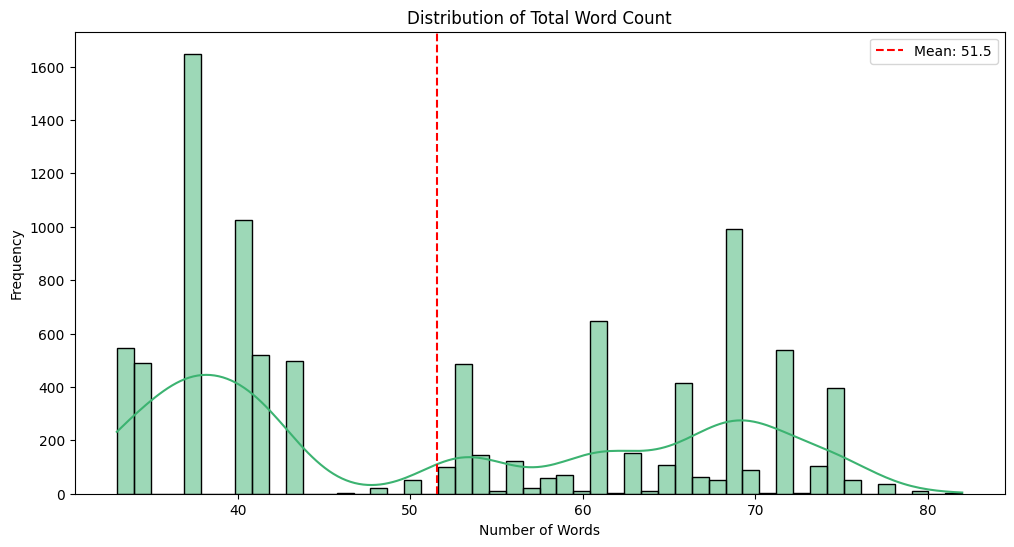


--- 出現頻度の高い単語 TOP 10 ---
->: 27755回
=: 22387回
the: 18194回
m: 14410回
in: 11344回
are: 11058回
for: 9658回
alice's: 9500回
wonderland,: 9500回
now,: 9500回


In [ ]:
#train dataの単語数計測
!pip install pandas matplotlib seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. データの読み込み
df = pd.read_csv('train.csv')

# 2. 単語数をカウントする関数（空白で区切って数える）
def count_words(text):
    if pd.isna(text):
        return 0
    return len(str(text).split())

# 3. prompt と answer それぞれの単語数を計算
df['words_prompt'] = df['prompt'].apply(count_words)
df['words_answer'] = df['answer'].apply(count_words)
df['total_words'] = df['words_prompt'] + df['words_answer']

# 4. 統計情報の表示
print("--- 単語数の統計データ ---")
print(df[['words_prompt', 'words_answer', 'total_words']].describe().round(1))

# 5. 可視化（ヒストグラム）
plt.figure(figsize=(12, 6))
sns.histplot(df['total_words'], bins=50, color='mediumseagreen', kde=True)
plt.title('Distribution of Total Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.axvline(df['total_words'].mean(), color='red', linestyle='--', label=f"Mean: {df['total_words'].mean():.1f}")
plt.legend()
plt.show()

# 6. おまけ：よく使われている単語を少し覗いてみる（データの中身理解）
from collections import Counter
all_text = " ".join(df['prompt'].astype(str)) + " " + " ".join(df['answer'].astype(str))
words = all_text.lower().split()
common_words = Counter(words).most_common(10)
print("\n--- 出現頻度の高い単語 TOP 10 ---")
for word, freq in common_words:
    print(f"{word}: {freq}回")

In [6]:
#Vocabサイズとトークン数
!pip install sentencepiece

import sentencepiece as spm

# 1. 訓練用のテキストファイルを作成 (promptとanswerを結合)
with open('text_for_tok.txt', 'w') as f:
    f.write("\n".join(df['prompt'].astype(str) + " " + df['answer'].astype(str)))

# 2. 異なるVocabサイズでトークナイザーを試作する関数
def train_and_count(v_size):
    spm.SentencePieceTrainer.train(
        input='text_for_tok.txt', model_prefix=f'm_{v_size}', vocab_size=v_size
    )
    sp_test = spm.SentencePieceProcessor(model_file=f'm_{v_size}.model')

    # 全データのトークン数を合計
    total_tokens = sum([len(sp_test.encode_as_ids(str(t))) for t in df['prompt']])
    return total_tokens

# 3. 複数のサイズで比較
sizes = [4000, 8000, 16000]
results = {s: train_and_count(s) for s in sizes}

for s, count in results.items():
    print(f"Vocabサイズ {s}: 合計トークン数 {count}")

Vocabサイズ 4000: 合計トークン数 1025678
Vocabサイズ 8000: 合計トークン数 1004985
Vocabサイズ 16000: 合計トークン数 969596
